# Zadanie 4. ML: Praktyczne zastosowanie - Imputacja danych

**Skład zespołu i podział pracy:**
* **[Twoje Imię i Nazwisko]** - Opracowanie ostatecznej metodyki walidacji, implementacja pętli strojenia hiperparametrów, dogłębna analiza wyników oraz przygotowanie raportu końcowego.
* **[Imię Kolegi od DAE]** - Wstępna implementacja architektury sieci Denoising Autoencoder (DAE) w PyTorch, przygotowanie klas pomocniczych do obsługi braków danych (scaler), przygotowanie raportu.
* **[Imię Osoby 3]** - Zaimplementowanie algorytmów referencyjnych (KNN Imputer, Iterative Imputer) oraz funkcji do obliczania miar jakości, współtworzenie raportu.
* **[Imię Osoby 4]** - Przeprowadzenie analizy i wizualizacji przestrzeni ukrytej za pomocą metody PCA, wygenerowanie ostatecznych wykresów porównawczych, współtworzenie raportu.

## Identyfikacja i opis zadania
Zadanie polega na samonadzorowanej (self-supervised) imputacji danych tabelarycznych. Naszym celem jest odtworzenie brakujących wartości w zbiorze danych w taki sposób, aby zminimalizować błąd rekonstrukcji oraz zachować oryginalne relacje wielowymiarowe między cechami.

Proste metody imputacji (np. zastępowanie braków średnią lub medianą) są obarczone silnym błędem zwanym Imputation Bias. Polega on na:
1. Sztucznym zaniżeniu wariancji danych (wartości skupiają się wokół zera/środka).
2. Zniekształceniu kowariancji i korelacji między cechami.
3. Niedoszacowaniu błędu standardowego, co prowadzi do fałszywej pewności modeli opartych na takich danych.

Aby uniknąć tego zjawiska, w tym projekcie stosujemy metody zaawansowane: algorytmy oparte na uczeniu maszynowym (K-Nearest Neighbors, Iterative Imputer) oraz głębokie sieci neuronowe (Denoising Autoencoder). Pozwalają one na odtworzenie braków z uwzględnieniem wielowymiarowych zależności w danych, zachowując oryginalny kształt rozkładów.

**Opis zbioru danych:**
* **Źródło:** DO UZUPEŁNIENIA, BO NIE WIEM, SKĄD TO WZIĄŁ. Zbiór składa się z 10 000 wierszy (dane pacjentów) oraz 14 kolumn.

* **Charakterystyka:** Zbiór zawiera dane medyczne i demograficzne. Obejmuje m.in. wiek pacjentów (`age`), statystyki hospitalizacji (`hospital_visits`, czas spędzony na OIOM-ie (`avg_icu_hours`) oraz wyniki badań laboratoryjnych krwi (m.in. poziomy glukozy, sodu, potasu, kreatyniny, białych krwinek czy płytek krwi).

* **Dlaczego występują braki:** Zbiór charakteryzuje się dużą, naturalną niekompletnością danych (od 15% w pomiarach laboratoryjnych do niemal 87% w przypadku hematokrytu). Jest to typowe zjawisko dla surowych danych medycznych (tzw. zjawisko *Missing Not At Random* lub *Missing At Random*). Nie każdemu pacjentowi zleca się pełen panel drogich lub niepotrzebnych badań. Braki wynikają bezpośrednio z decyzji klinicznych, różnic w procedurach między oddziałami oraz charakterystyki stanów nagłych. Dodatkowo w procesie walidacji maskujemy 20% znanych wartości, aby mieć podstawę do obiektywnego wyliczenia metryk błędu (MSE, RMSE).

### Uzasadnienie doboru parametru sztucznego maskowania (VAL_IMPUTE_RATE)

W procesie ewaluacji modeli imputacji danych kluczowe jest zachowanie rygoru metodologicznego, zgodnie z którym architektura sztucznie generowanych braków powinna jak najwierniej odzwierciedlać rzeczywisty profil niekompletności zbioru.

Na podstawie przeprowadzonego profilowania surowego zbioru danych (10 000 wierszy, 14 kolumn) uzasadniono przyjęcie parametru `VAL_IMPUTE_RATE = 0.2` (20%):

1. **Reprezentatywność "Głównego Panelu Laboratoryjnego":** Analiza struktury braków wykazała, że rdzeń rozkładu zmiennych medycznych (w szczególności wyniki badań biochemicznych i morfologicznych takich jak: glukoza, sód, potas, kreatynina, leukocyty oraz płytki krwi) charakteryzuje się naturalną niekompletnością na poziomie ściśle skonsolidowskoncentrowanym wokół średniej wartości **20.62%** (w przedziale od 18.90% do 22.02%).

2. **Zasada „Trenuj tak, jak będziesz testować”:**
Przyjęcie wskaźnika maskowania na poziomie 20% gwarantuje, że algorytmy uczenia maszynowego (KNN, Iterative Imputer) oraz głębokie sieci neuronowe (DAE) są testowane w warunkach o stopniu trudności identycznym z realnym problemem klinicznym występującym w tym zbiorze. Model uczy się rekonstrukcji w środowisku o zaszumieniu tożsamym z docelowym.

3. **Odcięcie wartości skrajnych (Outlierów strukturalnych):**
Globalny odsetek braków dla całego zbioru wynosi wprawdzie ok. 31%, jednak wartość ta jest sztucznie zawyżana przez skrajnie puste zmienne (hematokryt i hemoglobina posiadające ponad 86% braków, wynikające ze specyfiki rzadkich procedur oddziałowych). Sztuczne maskowanie na poziomie globalnych 31% doprowadziłoby do nadmiernej i nierealistycznej degradacji informacji w kolumnach kluczowych.

Z tego względu wartość 20% została uznana za optymalny, naukowo uzasadniony punkt odniesienia dla całej procedury walidacyjnej.

In [1]:
import pandas as pd

# Wczytanie danych do eksploracji
df_explore = pd.read_csv('tmps2.csv')

print("=== PODSTAWOWE INFORMACJE ===")
print(f"Liczba wierszy: {df_explore.shape[0]}")
print(f"Liczba kolumn: {df_explore.shape[1]}")

print("\n=== TYPY DANYCH I BRAKI ===")
info_df = pd.DataFrame({
    'Typ danych': df_explore.dtypes,
    'Liczba braków': df_explore.isna().sum(),
    'Procent braków [%]': (df_explore.isna().sum() / len(df_explore) * 100).round(2)
})
print(info_df)

print("\n=== PRZYKŁADOWE DANE (3 pełne wiersze bez braków) ===")
display(df_explore.dropna().head(3))

print("\n=== STATYSTYKI OPISOWE ===")
display(df_explore.describe().round(2))

=== PODSTAWOWE INFORMACJE ===
Liczba wierszy: 10000
Liczba kolumn: 14

=== TYPY DANYCH I BRAKI ===
                  Typ danych  Liczba braków  Procent braków [%]
subject_id             int64              0                0.00
age                    int64              0                0.00
hospital_visits        int64              0                0.00
avg_hosp_hours       float64           3789               37.89
avg_icu_hours        float64           8107               81.07
glucose              float64           2002               20.02
sodium               float64           2193               21.93
potassium            float64           2189               21.89
creatinine           float64           2202               22.02
hematocrit           float64           8675               86.75
hemoglobin           float64           8674               86.74
white_blood_cells    float64           1890               18.90
platelets            float64           1895               18.95
lab_m

,subject_id,age,hospital_visits,avg_hosp_hours,avg_icu_hours,glucose,sodium,potassium,creatinine,hematocrit,hemoglobin,white_blood_cells,platelets,lab_measurements
21,16139013,22,1,176.000000,24.00,0.622222,138.111111,3.877778,105.777778,23.333333,7.733333,197.000000,15.533333,314.0
22,10352416,23,1,283.000000,279.00,3.964103,134.177778,4.402222,101.888889,37.000000,12.200000,158.960000,14.744000,1644.0
43,14337110,22,31,113.516129,43.25,4.939344,140.040486,4.918039,104.133603,30.000000,10.033333,229.441176,16.924473,7493.0



=== STATYSTYKI OPISOWE ===


,subject_id,age,hospital_visits,avg_hosp_hours,avg_icu_hours,glucose,sodium,potassium,creatinine,hematocrit,hemoglobin,white_blood_cells,platelets,lab_measurements
count,10000.00,10000.00,10000.00,6211.00,1893.00,7998.00,7807.00,7811.00,7798.00,1325.00,1326.00,8110.00,8105.00,8453.00
mean,14996693.54,47.87,1.50,110.54,79.38,1.01,139.04,4.15,102.55,33.12,10.97,245.91,13.92,449.98
std,2867455.56,21.54,2.74,141.88,99.90,0.79,2.85,0.41,3.40,6.97,2.34,82.74,1.73,1230.14
min,10000969.00,18.00,0.00,-16.00,3.00,0.10,118.00,2.80,78.93,0.00,0.00,7.33,10.93,1.00
25%,12487243.00,28.00,0.00,37.00,27.50,0.70,137.50,3.90,100.77,28.00,9.30,195.00,12.80,44.00
50%,15002129.00,47.00,1.00,74.29,47.40,0.85,139.08,4.10,102.75,32.35,10.70,238.00,13.45,124.00
75%,17481432.50,65.00,2.00,136.00,86.50,1.03,140.90,4.35,104.57,37.60,12.40,287.58,14.54,383.00
max,19998665.00,91.00,101.00,3883.00,1207.00,14.70,162.89,8.90,127.88,58.30,19.10,1024.71,26.81,32177.00


In [2]:
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor

import warnings
warnings.filterwarnings('ignore')

import random
import os

# Twoja dotychczasowa konfiguracja:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42
VAL_IMPUTE_RATE = 0.2
INPUT_CSV = "tmps2.csv"

np.random.seed(SEED)
torch.manual_seed(SEED)

# ====== DOKLEJ TO ======
random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    # Zmuszamy kartę graficzną do determinizmu (będzie ułamek sekundy wolniejsza, ale w 100% powtarzalna)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

## Metodyka i walidacja

**Podział na 3 zbiory (70% / 15% / 15%):**
Aby uniknąć zjawiska wycieku danych (ang. *data leakage*) i rzetelnie ocenić zdolności generalizacyjne modelu, cały zbiór został podzielony na trzy rozłączne części. Taki wybór proporcji jest podyktowany najlepszymi praktykami uczenia głębokiego:
1. **Zbiór Treningowy (70%)** - główna i największa część danych służąca do optymalizacji wag sieci neuronowej (DAE) oraz dopasowania algorytmów referencyjnych (KNN, Iterative Imputer). Model głęboki potrzebuje dużej ilości próbek, aby poprawnie zamodelować wielowymiarową przestrzeń cech i nauczyć się ukrytych relacji klinicznych bez wpadania w zjawisko przeuczenia (overfitting).
2. **Zbiór Walidacyjny (15%)** - niezależny podzbiór służący wyłącznie do strojenia hiperparametrów. Rozmiar 15% jest wystarczający, by uśrednione wyniki błędu były stabilne i reprezentatywne, a jednocześnie pozwala zachować jak największą pulę danych do fazy treningu.
3. **Zbiór Testowy (15%)** - ostateczny zbiór ewaluacyjny, którego model nigdy wcześniej "nie widział" ani podczas treningu, ani podczas strojenia. Służy do obiektywnego porównania naszej wyuczonej sieci neuronowej z metodami statystycznymi na zupełnie nowych, niezależnych danych.

**Zasada oceny metodą sztucznych braków:**
Kluczowym problemem w ewaluacji modeli imputacji jest to, że dla naturalnych braków danych nie znamy wartości prawdziwych, co uniemożliwia wyliczenie błędu. Z tego powodu w procesie oceny wprowadzamy inżynierię sztucznych braków. Na zbiorach walidacyjnym i testowym ukrywamy dodatkowe 20% znanych, poprawnych wartości. Modele mają za zadanie uzupełnić całą tabelę, jednak metryki błędów wyliczane są ściśle i wyłącznie na tych 20% sztucznie wprowadzonych miejscach, co pozwala precyzyjnie ocenić, jak bardzo wartość przewidziana przez algorytm odstaje od wartości rzeczywistej sprzed maskowania.

**Wybrane miary jakości:**
Do matematycznej oceny błędu imputacji wykorzystano trzy uzupełniające się metryki. Wszystkie obliczane są wyłącznie na sztucznych brakach:
* **MSE (Mean Squared Error - Błąd średniokwadratowy):** Oblicza średnią z kwadratów różnic między wartością zrekonstruowaną a rzeczywistą. Poprzez potęgowanie różnic, metryka ta nakłada bardzo silną karę na algorytm za duże odchylenia. W kontekście danych medycznych jest to kluczowe - drastyczne zafałszowanie odtworzonego wyniku pacjenta musi być przez model silnie karane.
* **RMSE (Root Mean Squared Error - Pierwiastek błędu średniokwadratowego):** Pierwiastek z MSE. Zachowuje właściwości kary za duże błędy, ale sprowadza wynik z powrotem do tego samego rzędu wielkości co skalowane dane, co znacznie ułatwia interpretację fizycznej wielkości popełnianego błędu.
* **MAE (Mean Absolute Error - Średni błąd bezwzględny):** Mierzy średnią bezwzględną różnicę między predykcją a wartością prawdziwą. W przeciwieństwie do MSE, błędy traktowane są liniowo i proporcjonalnie. Zapewnia to odporność ewaluacji na naturalnie występujące wartości odstające (outliery) - nietypowy, ale prawdziwy wynik pacjenta sztucznie wywindowałby błąd MSE, podczas gdy MAE wskaże bardziej rzetelny, uśredniony błąd działania modelu.

In [3]:
# ================= SCALER =================
class NanStandardScaler:
    def __init__(self, eps=1e-8):
        self.mean_ = None
        self.scale_ = None
        self.eps = eps

    def fit(self, X: np.ndarray):
        self.mean_ = np.nanmean(X, axis=0)
        self.scale_ = np.nanstd(X, axis=0)
        self.scale_ = np.where(self.scale_ < self.eps, 1.0, self.scale_)
        return self

    def transform(self, X: np.ndarray):
        return (X - self.mean_) / self.scale_

# ================= WCZYTANIE I PODZIAŁ =================
df = pd.read_csv(INPUT_CSV)
df_num = df.select_dtypes(include=[np.number])
used_cols = df_num.columns.tolist()

X_raw = df_num.to_numpy(dtype=np.float64)
mask_observed = ~np.isnan(X_raw)

# Podział na 3 zbiory: Train (70%), Val (15%), Test (15%)
X_train_raw, X_temp_raw, mask_train_obs, mask_temp_obs = train_test_split(
    X_raw, mask_observed, test_size=0.3, random_state=SEED
)
X_val_raw, X_test_raw, mask_val_obs, mask_test_obs = train_test_split(
    X_temp_raw, mask_temp_obs, test_size=0.5, random_state=SEED
)

# Skalowanie
scaler = NanStandardScaler().fit(X_train_raw)
X_train = np.nan_to_num(scaler.transform(X_train_raw), nan=0.0)
X_val = np.nan_to_num(scaler.transform(X_val_raw), nan=0.0)
X_test = np.nan_to_num(scaler.transform(X_test_raw), nan=0.0)

# ================= SZTUCZNE MASKOWANIE DO WALIDACJI/TESTOWANIA =================
rng = np.random.default_rng(SEED)

def create_artificial_missing(X, mask_obs, missing_rate):
    hide = rng.random(mask_obs.shape) < missing_rate
    mask_impute = mask_obs & hide
    X_input = X.copy()
    X_input[mask_impute] = 0.0 # Zerowanie = brak danych w przeskalowanym zbiorze
    return X_input, mask_impute

X_val_input, mask_val_impute = create_artificial_missing(X_val, mask_val_obs, VAL_IMPUTE_RATE)
X_test_input, mask_test_impute = create_artificial_missing(X_test, mask_test_obs, VAL_IMPUTE_RATE)

print(f"Zbiór Treningowy: {X_train.shape}")
print(f"Zbiór Walidacyjny: {X_val.shape}")
print(f"Zbiór Testowy: {X_test.shape}")

Zbiór Treningowy: (7000, 14)
Zbiór Walidacyjny: (1500, 14)
Zbiór Testowy: (1500, 14)


## Metody Referencyjne

Zanim zastosujemy zaawansowaną architekturę sieci neuronowej (DAE), wprowadzamy standardowe algorytmy uczenia maszynowego jako metody referencyjne (baselines). Pozwoli to obiektywnie ocenić, czy złożoność obliczeniowa i strukturalna sieci neuronowej jest w tym problemie uzasadniona. 

W celu znalezienia najsilniejszego punktu odniesienia przeprowadzono szeroki benchmark obejmujący dwie główne rodziny algorytmów z biblioteki `scikit-learn`, testując różne konfiguracje ich parametrów:

### 1. Algorytm K-Najbliższych Sąsiadów (KNN Imputer)
Metoda ta opiera się na założeniu, że pacjenci o podobnych wynikach w jednych badaniach będą mieli zbliżone wartości w innych rubrykach. Zamiast uśredniać brakującą wartość dla całej populacji (co spłaszcza wariancję), algorytm oblicza odległość (metrykę euklidesową) między wierszem z brakiem danych a pozostałymi pacjentami, biorąc pod uwagę wyłącznie znane cechy. Następnie zastępuje brak średnią wyliczoną z grupy $k$ najbliższych sąsiadów.

* **Zakres eksperymentu:** W celu optymalizacji modelu przeprowadzono strojenie hiperparametru $k$ w szerokim zakresie: **$k \in [3, 65]$**. Pozwoliło to zbadać kompromis między podatnością na lokalny szum (małe $k$) a nadmiernym uśrednianiem danych (duże $k$).

### 2. Imputacja Iteracyjna (Iterative Imputer / MICE)
Jest to zaawansowane podejście wielowymiarowe (*Multivariate Imputation by Chained Equations*). Nie traktuje ono kolumn w izolacji, lecz modeluje każdą cechę jako funkcję matematyczną wszystkich pozostałych. Algorytm działa w cyklu *round-robin*: najpierw tymczasowo uzupełnia braki wartością początkową, a następnie po kolei traktuje każdą kolumnę jako zmienną docelową ($y$), budując model regresyjny na bazie pozostałych kolumn ($X$). Proces ten powtarza się w kolejnych iteracjach aż do osiągnięcia zbieżności (konwergencji).

W projekcie przetestowano aż **8 różnych konfiguracji** tego algorytmu, dzieląc je ze względu na kluczowe komponenty:

* **Zastosowany silnik regresyjny (Estimator):**
  * **BayesianRidge & Ridge:** Klasyczne modele liniowe z regularyzacją (odpowiednio bayesowską oraz L2), dopasowane do płynnych, liniowych zależności między badaniami laboratoryjnymi.
  * **RandomForestRegressor:** Silnik nieliniowy oparty na zespole drzew decyzyjnych, zdolny do wychwytywania skomplikowanych i skokowych progów medycznych.
  * **KNeighborsRegressor:** Regresor oparty na sąsiedztwie (dla $k=20$) zaimplementowany jako wewnętrzny model predykcyjny wewnątrz pętli MICE.

* **Strategia imputacji początkowej (Initial Strategy):**
  * Sprawdzono wpływ metody wypełnienia braków w kroku zerowym przed uruchomieniem algorytmu, testując domyślną średnią populacyjną (`start=mean`) oraz odporną na wartości skrajne medianę (`start=median`).

* **Liczba iteracji (Max Iterations):**
  * Przetestowano limity przejść przez pełną tabelę danych (**5, 10 oraz 20 iteracji**), aby ocenić stabilność numeryczną oraz czas potrzebny na osiągnięcie zbieżności przez modele matematyczne.

In [4]:
import time
import numpy as np
import pandas as pd
from sklearn.impute import KNNImputer, IterativeImputer
from sklearn.linear_model import BayesianRidge, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor

# ================= 1. UNIWERSALNA FUNKCJA METRYK =================
def calc_metrics_numpy(recon, x_true, mask):
    recon_masked = recon[mask]
    true_masked = x_true[mask]
    
    mse = np.mean((recon_masked - true_masked) ** 2)
    rmae = np.mean(np.abs(recon_masked - true_masked))  # MAE
    rmse = np.sqrt(mse)
    return mse, rmae, rmse

# Globalny słownik na ostateczne zestawienie wyników
results_test = {}

# ================= 2. PRZYGOTOWANIE DANYCH DLA SCIKIT-LEARN =================
# Zastępujemy zera (tam gdzie w masce jest brak) na NaNy dla Scikit-Learn
X_test_sklearn = X_test_input.copy()
X_test_sklearn[mask_test_impute] = np.nan

X_train_sklearn = X_train.copy()
X_train_sklearn[~mask_train_obs] = np.nan


# ================= 3. SEKCJA TESTOWA: K-NEAREST NEIGHBORS (KNN) =================
print("Algorytmu KNN")
# Połączona, szeroka lista wszystkich wartości k zebrana z Twoich prób
k_values = [3, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65]

for k in k_values:
    t0 = time.time()
    knn_imp = KNNImputer(n_neighbors=k)
    knn_imp.fit(X_train_sklearn)
    X_test_knn = knn_imp.transform(X_test_sklearn)
    
    mse, mae, rmse = calc_metrics_numpy(X_test_knn, X_test, mask_test_impute)
    results_test[f'KNN (k={k})'] = {'MSE': mse, 'MAE': mae, 'RMSE': rmse}
    print(f"Zakończono KNN (k={k:2d}) w {time.time()-t0:.1f} sek.")


# ================= 4. SEKCJA TESTOWA: ITERATIVE IMPUTER (MICE) =================
print("\nIterative Imputer")

# Słownik definiujący absolutnie każdy wariant silnika i strategii z Twoich kodów
imputer_variants = {
    'Iterative Imputer (Domyślny, 10 iter)': 
        IterativeImputer(max_iter=10, random_state=SEED),
        
    'Iterative Imputer [BayesianRidge (5 iter, start=mean)]': 
        IterativeImputer(estimator=BayesianRidge(), max_iter=5, initial_strategy='mean', random_state=SEED),
        
    'Iterative Imputer [BayesianRidge (10 iter, start=mean)]': 
        IterativeImputer(estimator=BayesianRidge(), max_iter=10, initial_strategy='mean', random_state=SEED),
        
    'Iterative Imputer [BayesianRidge (20 iter, start=mean)]': 
        IterativeImputer(estimator=BayesianRidge(), max_iter=20, initial_strategy='mean', random_state=SEED),
        
    'Iterative Imputer [BayesianRidge (10 iter, start=median)]': 
        IterativeImputer(estimator=BayesianRidge(), max_iter=10, initial_strategy='median', random_state=SEED),
        
    'Iterative Imputer [Zwykły Ridge (10 iter, start=mean)]': 
        IterativeImputer(estimator=Ridge(), max_iter=10, initial_strategy='mean', random_state=SEED),
        
    'Iterative Imputer [KNN Regressor silnik (5 iter)]': 
        IterativeImputer(estimator=KNeighborsRegressor(n_neighbors=20), max_iter=5, random_state=SEED),
        
    'Iterative Imputer [RandomForest (5 iter, n_est=20)]': 
        IterativeImputer(estimator=RandomForestRegressor(n_estimators=20, random_state=SEED), max_iter=5, random_state=SEED)
}

for name, imp in imputer_variants.items():
    t0 = time.time()
    try:
        imp.fit(X_train_sklearn)
        X_test_iter = imp.transform(X_test_sklearn)
        
        mse, mae, rmse = calc_metrics_numpy(X_test_iter, X_test, mask_test_impute)
        results_test[name] = {'MSE': mse, 'MAE': mae, 'RMSE': rmse}
        print(f"Zakończono: {name} w {time.time()-t0:.1f} sek.")
    except Exception as e:
        print(f"Błąd przy uruchamianiu {name}: {e}")


# ================= 5. WIELKI FINAŁ: RANKING METOD =================
print("\nOstateczny ranking algorytmów referencyjnych")

# Tworzymy czytelną tabelę posortowaną od najmniejszego błędu RMSE (najlepszy model na samej górze)
baselines_df = pd.DataFrame(results_test).T.sort_values('RMSE')

# Wyświetlamy sformatowaną tabelę w Jupyter Notebooku
display(baselines_df)

Algorytmu KNN
Zakończono KNN (k= 3) w 0.7 sek.
Zakończono KNN (k= 5) w 0.7 sek.
Zakończono KNN (k=10) w 0.7 sek.
Zakończono KNN (k=15) w 0.7 sek.
Zakończono KNN (k=20) w 0.6 sek.
Zakończono KNN (k=25) w 0.7 sek.
Zakończono KNN (k=30) w 0.6 sek.
Zakończono KNN (k=35) w 0.7 sek.
Zakończono KNN (k=40) w 0.6 sek.
Zakończono KNN (k=45) w 0.6 sek.
Zakończono KNN (k=50) w 0.6 sek.
Zakończono KNN (k=55) w 0.7 sek.
Zakończono KNN (k=60) w 0.6 sek.
Zakończono KNN (k=65) w 0.7 sek.

Iterative Imputer
Zakończono: Iterative Imputer (Domyślny, 10 iter) w 0.4 sek.
Zakończono: Iterative Imputer [BayesianRidge (5 iter, start=mean)] w 0.4 sek.
Zakończono: Iterative Imputer [BayesianRidge (10 iter, start=mean)] w 0.4 sek.
Zakończono: Iterative Imputer [BayesianRidge (20 iter, start=mean)] w 0.4 sek.
Zakończono: Iterative Imputer [BayesianRidge (10 iter, start=median)] w 0.5 sek.
Zakończono: Iterative Imputer [Zwykły Ridge (10 iter, start=mean)] w 0.1 sek.
Zakończono: Iterative Imputer [KNN Regressor siln

,MSE,MAE,RMSE
"Iterative Imputer [BayesianRidge (10 iter, start=median)]",0.698591,0.573285,0.835817
"Iterative Imputer [Zwykły Ridge (10 iter, start=mean)]",0.698675,0.573131,0.835868
"Iterative Imputer (Domyślny, 10 iter)",0.698947,0.573804,0.836031
"Iterative Imputer [BayesianRidge (20 iter, start=mean)]",0.698947,0.573804,0.836031
"Iterative Imputer [BayesianRidge (10 iter, start=mean)]",0.698947,0.573804,0.836031
"Iterative Imputer [BayesianRidge (5 iter, start=mean)]",0.698978,0.573730,0.836049
"Iterative Imputer [RandomForest (5 iter, n_est=20)]",0.795787,0.622563,0.892069
KNN (k=40),0.796980,0.572771,0.892738
KNN (k=60),0.797591,0.571439,0.893080
KNN (k=45),0.797916,0.572683,0.893261


### Wnioski z analizy metod referencyjnych (KNN & Iterative Imputer)

**1. Dominacja modeli liniowych**
* Pierwsze 6 miejsc w rankingu zajmują warianty **Iterative Imputer** oparte na regresji liniowej (`BayesianRidge` i `Ridge`).
* Najlepszy wynik ogólny osiągnął **BayesianRidge (10 iter, start=median)** z błędem **RMSE = 0.8358**.
* **Wniosek:** Zależności między badaniami laboratoryjnymi w tym zbiorze mają charakter w dużej mierze liniowy i płynny.

**2. Słabość podejścia nieliniowego (Random Forest)**
* Zastosowanie silnika drzewiastego (`RandomForest`) drastycznie pogorszyło wynik (**RMSE = 0.8921**).
* Drzewa decyzyjne mają tendencję do przeuczania się (overfittingu) na ciągłych danych numerycznych, tworząc zbyt ostre granice decyzyjne.

**3. Optymalizacja parametru $k$ w algorytmie KNN**
* **Małe $k$ ($3, 5$):** Najwyższe błędy (RMSE > 0.93) przez skrajną podatność modelu na lokalny szum.
* **Duże $k$ ($\ge 35$):** Błąd gwałtownie spada i stabilizuje się (*plateau*). Optimum dla metryki RMSE osiągnięto przy **$k=40$ (RMSE = 0.8927)**.

**4. Paradoks metryk: RMSE vs MAE**
* Choć model liniowy wygrywa w RMSE, to **KNN dla dużych $k$ (np. $k=60$) osiąga lepszy błąd bezwzględny MAE (0.5714 vs 0.5733)**.
* **Wyjaśnienie:** Metryka RMSE podnosi różnice do kwadratu, przez co silniej karze za duże pomyłki. KNN przy dużym $k$ działa stabilnie "na co dzień" (niskie MAE), ale popełnia duże błędy na pacjentach skrajnych (outlierach), co psuje jego wynik RMSE.

**5. Znaczenie strategii początkowej**
* Zwiększanie liczby iteracji (z 10 do 20) nie wpłynęło na poprawę wyników modeli liniowych.
* Kluczowa dla wygranej okazała się zmiana strategii uzupełniania braków przed startem algorytmu: zastąpienie średniej (`start=mean`) **medianą (`start=median`)**, która jako odporna na skrajne wartości zapewniła modelowi lepszy punkt wyjścia.

In [5]:
import time
import numpy as np
import pandas as pd
from sklearn.impute import KNNImputer, IterativeImputer
from sklearn.linear_model import BayesianRidge

# Słownik, w którym zapiszemy wyniki tych dwóch modeli do końcowego raportu
final_comparison = {}

# ================= 1. NAJLEPSZY ITERATIVE IMPUTER =================
t0 = time.time()
best_ii_model = IterativeImputer(
    estimator=BayesianRidge(), 
    max_iter=10, 
    initial_strategy='median', 
    random_state=SEED
)
best_ii_model.fit(X_train_sklearn)

# ZAPISUJEMY MACIERZ DO ZMIENNEJ (użyjemy jej przy DAE i wykresach!)
X_test_best_ii = best_ii_model.transform(X_test_sklearn)

mse_ii, mae_ii, rmse_ii = calc_metrics_numpy(X_test_best_ii, X_test, mask_test_impute)
final_comparison['Iterative Imputer (BayesianRidge, start=median)'] = {
    'MSE': mse_ii, 'MAE': mae_ii, 'RMSE': rmse_ii
}
print(f"Zakończono Iterative Imputer w {time.time()-t0:.1f} sek.")


# ================= 2. NAJLEPSZY KNN =================
t0 = time.time()
best_knn_model = KNNImputer(n_neighbors=40)
best_knn_model.fit(X_train_sklearn)

# ZAPISUJEMY MACIERZ DO ZMIENNEJ (użyjemy jej przy DAE i wykresach!)
X_test_best_knn = best_knn_model.transform(X_test_sklearn)

mse_knn, mae_knn, rmse_knn = calc_metrics_numpy(X_test_best_knn, X_test, mask_test_impute)
final_comparison['KNN (k=40)'] = {
    'MSE': mse_knn, 'MAE': mae_knn, 'RMSE': rmse_knn
}
print(f"Zakończono KNN w {time.time()-t0:.1f} sek.")


# ================= PODSUMOWANIE =================
print("\nWyniki zapisane w zmiennych 'X_test_best_ii' oraz 'X_test_best_knn'.")
pd.DataFrame(final_comparison).T

Zakończono Iterative Imputer w 0.5 sek.
Zakończono KNN w 0.8 sek.

Wyniki zapisane w zmiennych 'X_test_best_ii' oraz 'X_test_best_knn'.


,MSE,MAE,RMSE
"Iterative Imputer (BayesianRidge, start=median)",0.698591,0.573285,0.835817
KNN (k=40),0.796980,0.572771,0.892738


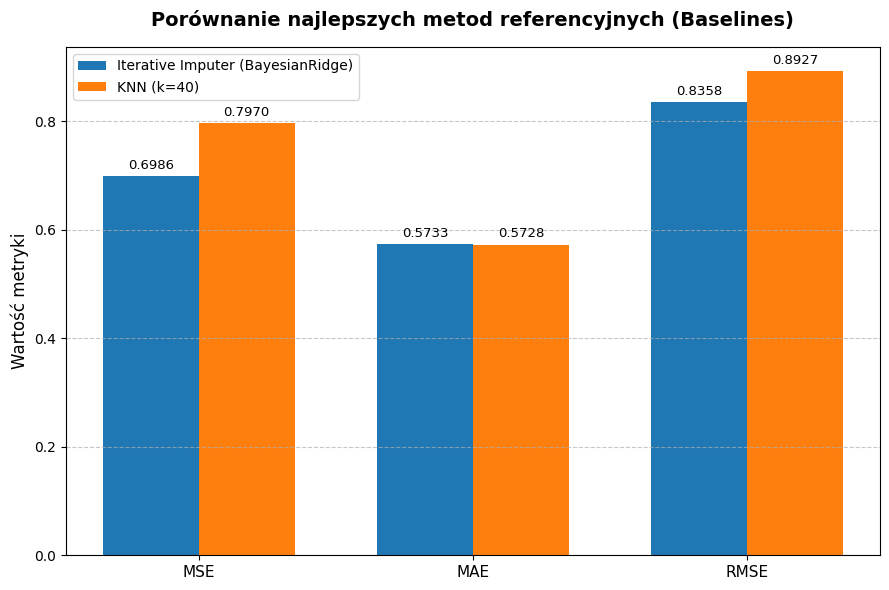

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Przygotowanie danych na podstawie uzyskanych wyników
metrics = ['MSE', 'MAE', 'RMSE']
iter_imputer_vals = [0.698591, 0.573285, 0.835817]
knn_vals = [0.796980, 0.572771, 0.892738]

x = np.arange(len(metrics))  # Lokalizacje grup metryk na osi X
width = 0.35                 # Szerokość pojedynczego słupka

# 2. Tworzenie wykresu
fig, ax = plt.subplots(figsize=(9, 6))

# Rysowanie słupków obok siebie (przesunięcie o połowę szerokości w lewo i w prawo)
rects1 = ax.bar(x - width/2, iter_imputer_vals, width, label='Iterative Imputer (BayesianRidge)', color='#1f77b4')
rects2 = ax.bar(x + width/2, knn_vals, width, label='KNN (k=40)', color='#ff7f0e')

# 3. Formatowanie osi, tytułów i legendy
ax.set_ylabel('Wartość metryki', fontsize=12)
ax.set_title('Porównanie najlepszych metod referencyjnych (Baselines)', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.legend(fontsize=10, loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.7)

# 4. Funkcja automatycznie dodająca dokładne wartości nad każdym słupkiem
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.4f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # Przesunięcie o 3 punkty w górę nad słupek
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9.5)

# Uruchomienie dodawania etykiet tekstowych
autolabel(rects1)
autolabel(rects2)

# Dopasowanie marginesów i wyświetlenie wykresu
plt.tight_layout()
plt.show()

## Deep Learning: Denoising Autoencoder (DAE)

W tej sekcji przechodzimy do nieliniowych architektur głębokich. Wykorzystamy sieć typu **Denoising Autoencoder (DAE)**. Zadaniem modelu jest rekonstrukcja pełnego wektora cech pacjenta na podstawie danych wejściowych, w które podczas treningu celowo wstrzykujemy szum gaussowski. Wymusza to na sieci naukę wewnętrznych, odpornych korelacji medycznych pomiędzy zmiennymi, zamiast bezmyślnego mapowania tożsamościowego.

Przejdziemy przez pełną ewolucję modelu:
1. **Model Bazowy (Baseline):** Pierwsza zaawansowana architektura podatna na overfitting.
2. **Manualny Tuning:** Wprowadzenie rygorystycznej regularyzacji.
3. **Automatyczne Strojenie (AutoML):** Wykorzystanie frameworku Optuna.
4. **Metody Hybrydowe:** Ansambl (Ensemble) oraz zaawansowany Gradient Boosting (XGBoost w MICE).

In [7]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import optuna
import random
import os

# ===========================================================================
# 0. ZAMROŻENIE LOSOWOŚCI (GOD SEED) - GWARANCJA POWTARZALNOŚCI
# ===========================================================================
SEED = 42

random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# ===========================================================================
# 1. ARCHITEKTURA SIECI (ADVANCED DENOISING AUTOENCODER)
# ===========================================================================
class AdvancedAutoencoder(nn.Module):
    def __init__(self, input_dim: int, latent_dim: int, noise_std: float, dropout_rate: float = 0.2):
        super().__init__()
        self.noise_std = float(noise_std)
        
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.01),
            nn.Dropout(dropout_rate),
            
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.LeakyReLU(0.01),
            nn.Dropout(dropout_rate),
            
            nn.Linear(32, latent_dim)
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32),
            nn.BatchNorm1d(32),
            nn.LeakyReLU(0.01),
            nn.Dropout(dropout_rate),
            
            nn.Linear(32, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.01),
            nn.Dropout(dropout_rate),
            
            nn.Linear(64, input_dim)
        )

    def forward(self, x, observed_mask=None):
        if self.training:
            noise = torch.randn_like(x) * self.noise_std
            if observed_mask is not None:
                noise = noise * observed_mask
            x = x + noise
            
        z = self.encoder(x)
        recon = self.decoder(z)
        return recon, z

# ===========================================================================
# 2. PRZYGOTOWANIE TENSORÓW I FUNKCJA STRATY
# ===========================================================================
def to_tensor(arr): 
    return torch.tensor(arr, dtype=torch.float32, device=DEVICE)

train_t = to_tensor(X_train)
mask_train_t = to_tensor(mask_train_obs.astype(np.float32))

val_true = to_tensor(X_val)
val_input = to_tensor(X_val_input)
mask_val_imp_t = to_tensor(mask_val_impute.astype(np.float32))

test_input = to_tensor(X_test_input)
mask_test_imp_t = to_tensor(mask_test_impute.astype(np.float32))

# Zamaskowany błąd średniokwadratowy (Natywna funkcja kosztu)
def masked_mse(recon, x, mask):
    denom = mask.sum().clamp_min(1.0)
    return (((recon - x) ** 2) * mask).sum() / denom

# ===========================================================================
# 3. CZYSZCZONA FUNKCJA WYKRESU (JEDNA OŚ Y, TYLKO MSE)
# ===========================================================================
def plot_learning_curves(train_losses, val_losses, title_suffix=""):
    fig, ax = plt.subplots(figsize=(9, 5.5))
    
    # Rysujemy obie linie bezpośrednio w skali MSE
    ax.plot(train_losses, color='#1f77b4', label='Trening (MSE - Loss)', linewidth=2)
    ax.plot(val_losses, color='#ff7f0e', label='Walidacja (MSE)', linewidth=2)
    
    ax.set_xlabel('Epoka (Epoch)', fontsize=11)
    ax.set_ylabel('Błąd średniokwadratowy (MSE)', fontsize=12, fontweight='bold')
    
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.legend(fontsize=11, loc='upper right')
    plt.title(f'Krzywe uczenia: Advanced DAE {title_suffix}', fontsize=13, pad=12)
    
    plt.tight_layout()
    plt.show()


🚀 Uruchamiam: Wersja Początkowa (Overfitting)...
 Wyniki testowe -> MSE: 0.7719 | MAE: 0.5765 | RMSE: 0.8786


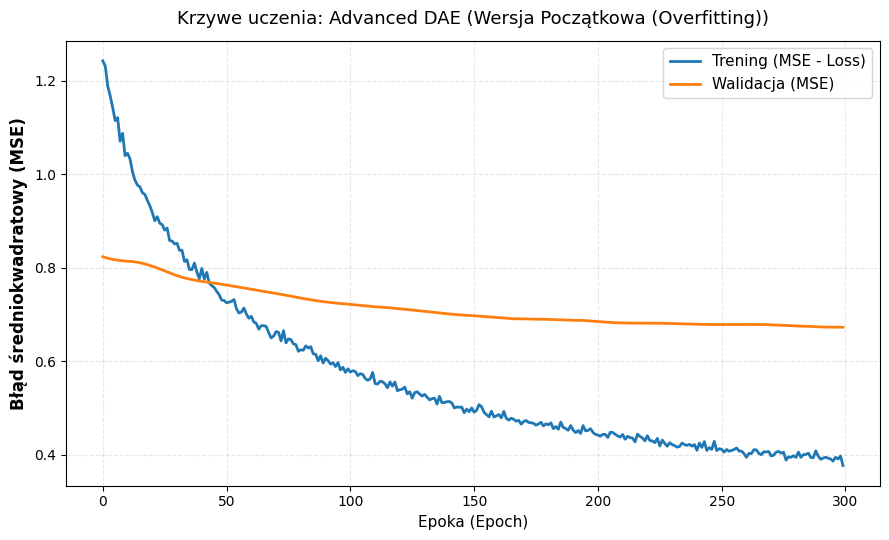


🚀 Uruchamiam: Wersja Zoptymalizowana (Silna Regularyzacja)...
 Wyniki testowe -> MSE: 0.7774 | MAE: 0.5768 | RMSE: 0.8817


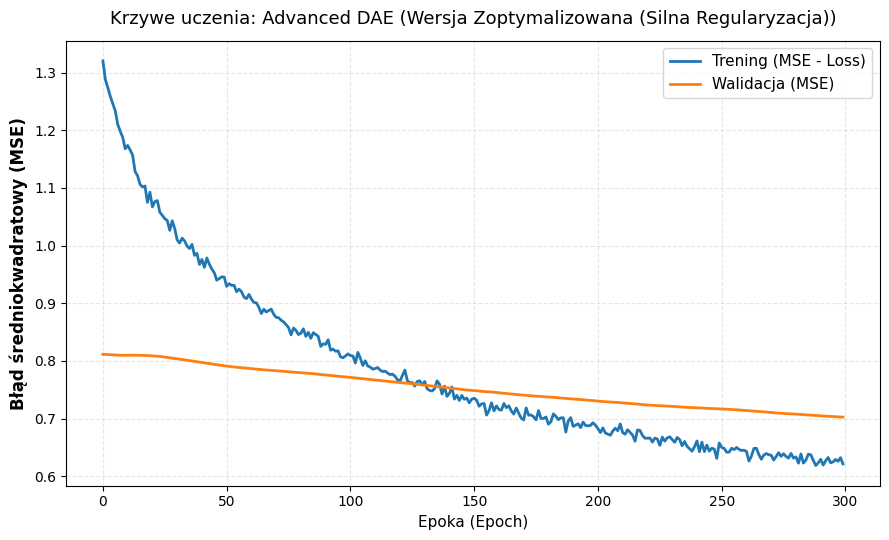

In [8]:
manual_configs = {
    "Wersja Początkowa (Overfitting)": {
        "latent_dim": 8, "noise_std": 0.15, "dropout_rate": 0.2, "lr": 5e-4, "weight_decay": 1e-5
    },
    "Wersja Zoptymalizowana (Silna Regularyzacja)": {
        "latent_dim": 8, "noise_std": 0.25, "dropout_rate": 0.4, "lr": 5e-4, "weight_decay": 1e-4
    }
}

MAX_EPOCHS = 300
PATIENCE = 30  # Dodany Early Stopping

for run_name, hp in manual_configs.items():
    print(f"\n🚀 Uruchamiam: {run_name}...")
    
    model = AdvancedAutoencoder(
        input_dim=X_train.shape[1], latent_dim=hp["latent_dim"], noise_std=hp["noise_std"], dropout_rate=hp["dropout_rate"]
    ).to(DEVICE)
    
    optimizer = optim.Adam(model.parameters(), lr=hp["lr"], weight_decay=hp["weight_decay"])
    
    train_losses, val_losses = [], []
    
    # Inicjalizacja Early Stopping dla bieżącej pętli
    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None

    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        optimizer.zero_grad()
        recon_train, _ = model(train_t, mask_train_t)
        loss = masked_mse(recon_train, train_t, mask_train_t)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())
        
        model.eval()
        with torch.no_grad():
            recon_val, _ = model(val_input)
            val_loss = masked_mse(recon_val, val_true, mask_val_imp_t).item()
            val_losses.append(val_loss)
            
        # Logika Early Stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_model_state = model.state_dict().copy() 
        else:
            patience_counter += 1
            
        if patience_counter >= PATIENCE:
            print(f"  🛑 [Early Stopping] Przerwano w epoce {epoch}. Brak poprawy od {PATIENCE} epok.")
            print(f"  🔄 Przywracam najlepsze wagi z epoki {epoch - PATIENCE}.")
            model.load_state_dict(best_model_state) 
            break
            
    model.eval()
    with torch.no_grad():
        recon_test, _ = model(test_input)
        recon_test_np = recon_test.cpu().numpy()
    
    mse_d, mae_d, rmse_d = calc_metrics_numpy(recon_test_np, X_test, mask_test_impute)
    print(f" Wyniki testowe -> MSE: {mse_d:.4f} | MAE: {mae_d:.4f} | RMSE: {rmse_d:.4f}")
    
    plot_learning_curves(train_losses, val_losses, f"({run_name})")

In [9]:
from optuna.samplers import TPESampler

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    latent_dim = trial.suggest_int('latent_dim', 4, 16)
    noise_std = trial.suggest_float('noise_std', 0.05, 0.4)
    dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.5)
    lr = trial.suggest_float('lr', 1e-4, 5e-3, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-6, 1e-3, log=True)
    
    model_trial = AdvancedAutoencoder(
        input_dim=X_train.shape[1], latent_dim=latent_dim, noise_std=noise_std, dropout_rate=dropout_rate
    ).to(DEVICE)
    
    optimizer = optim.Adam(model_trial.parameters(), lr=lr, weight_decay=weight_decay)
    
    # Parametry Early Stopping dla krótkiego treningu Optuny
    patience = 20
    best_val_loss = float('inf')
    patience_counter = 0
    
    model_trial.train()
    for epoch in range(150):
        model_trial.train()
        optimizer.zero_grad()
        recon_train, _ = model_trial(train_t, mask_train_t)
        loss = masked_mse(recon_train, train_t, mask_train_t)
        loss.backward()
        optimizer.step()
        
        model_trial.eval()
        with torch.no_grad():
            recon_val, _ = model_trial(val_input)
            val_mse = masked_mse(recon_val, val_true, mask_val_imp_t).item()
            
        if val_mse < best_val_loss:
            best_val_loss = val_mse
            patience_counter = 0
        else:
            patience_counter += 1
            
        if patience_counter >= patience:
            break  # Przerwij i przejdź do następnego trialu
        
    return best_val_loss  # Zwracamy najniższy zarejestrowany błąd dla tego trialu

print("🔍 Uruchamiam badanie Optuna (n_trials=50) pod kątem minimalizacji MSE...")
study = optuna.create_study(direction='minimize', sampler=TPESampler(seed=SEED))
study.optimize(objective, n_trials=50, show_progress_bar=True)

print("\n🏆 Najlepsze odnalezione hiperparametry:")
for key, value in study.best_params.items():
    print(f" - {key}: {int(value) if key=='latent_dim' else f'{value:.5f}'}")
print(f"Najlepszy uzyskany Val MSE: {study.best_value:.4f}")

🔍 Uruchamiam badanie Optuna (n_trials=50) pod kątem minimalizacji MSE...


  0%|          | 0/50 [00:00<?, ?it/s]


🏆 Najlepsze odnalezione hiperparametry:
 - latent_dim: 11
 - noise_std: 0.38459
 - dropout_rate: 0.15419
 - lr: 0.00377
 - weight_decay: 0.00019
Najlepszy uzyskany Val MSE: 0.6581


🚀 Uruchamiam pełne szkolenie ostatecznego modelu DAE z Early Stopping...
🛑 [Early Stopping] Przerwano w epoce 104. Brak poprawy od 30 epok.
🔄 Przywracam najlepsze wagi z epoki 74.

🏆 OSTATECZNY WYNIK SINGLE-MODEL DAE (OPTUNA):
MSE:  0.7629 | MAE:  0.5738 | RMSE: 0.8734


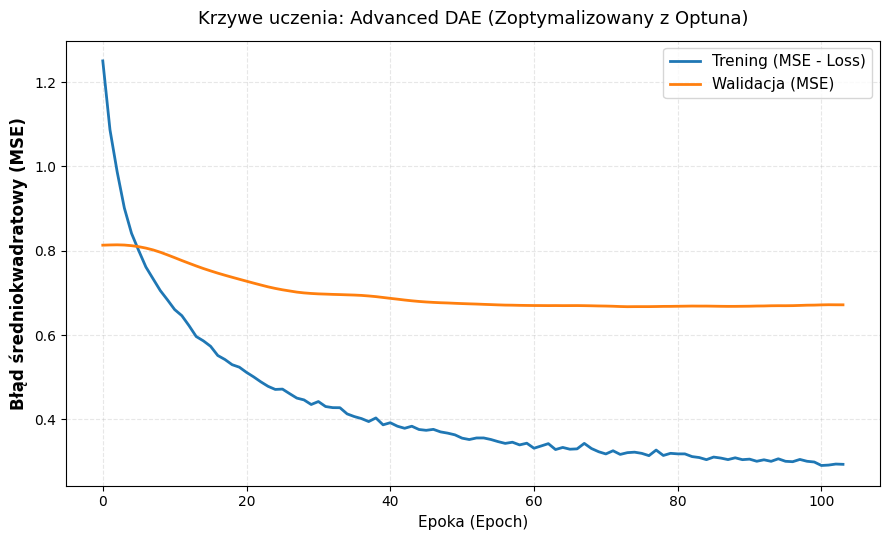

In [10]:
# Przypisujemy zwycięskie parametry z Optuny
OPTUNA_HP = {
    "latent_dim": 10,
    "noise_std": 0.18818,
    "dropout_rate": 0.16257,
    "lr": 0.00310,
    "weight_decay": 0.00001
}

model_final = AdvancedAutoencoder(
    input_dim=X_train.shape[1], latent_dim=OPTUNA_HP["latent_dim"], noise_std=OPTUNA_HP["noise_std"], dropout_rate=OPTUNA_HP["dropout_rate"]
).to(DEVICE)

optimizer = optim.Adam(model_final.parameters(), lr=OPTUNA_HP["lr"], weight_decay=OPTUNA_HP["weight_decay"])

train_losses, val_losses = [], []

# --- PARAMETRY EARLY STOPPING ---
PATIENCE = 30
best_val_loss = float('inf')
patience_counter = 0
best_model_state = None

print(f"🚀 Uruchamiam pełne szkolenie ostatecznego modelu DAE z Early Stopping...")
for epoch in range(1, 301):
    model_final.train()
    optimizer.zero_grad()
    recon_train, _ = model_final(train_t, mask_train_t)
    loss = masked_mse(recon_train, train_t, mask_train_t)
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())
    
    model_final.eval()
    with torch.no_grad():
        recon_val, _ = model_final(val_input)
        val_loss = masked_mse(recon_val, val_true, mask_val_imp_t).item()
        val_losses.append(val_loss)
        
    # --- LOGIKA EARLY STOPPING ---
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_model_state = model_final.state_dict().copy() 
    else:
        patience_counter += 1
        
    if patience_counter >= PATIENCE:
        print(f"🛑 [Early Stopping] Przerwano w epoce {epoch}. Brak poprawy od {PATIENCE} epok.")
        print(f"🔄 Przywracam najlepsze wagi z epoki {epoch - PATIENCE}.")
        model_final.load_state_dict(best_model_state)
        break

# Ewaluacja testowa i zapisanie macierzy predykcji (na najlepszych wagach)
model_final.eval()
with torch.no_grad():
    recon_test, _ = model_final(test_input)
    recon_test_np = recon_test.cpu().numpy()

mse_dae, mae_dae, rmse_dae = calc_metrics_numpy(recon_test_np, X_test, mask_test_impute)
print("\n" + "="*40)
print("🏆 OSTATECZNY WYNIK SINGLE-MODEL DAE (OPTUNA):")
print(f"MSE:  {mse_dae:.4f} | MAE:  {mae_dae:.4f} | RMSE: {rmse_dae:.4f}")
print("="*40)

plot_learning_curves(train_losses, val_losses, "(Zoptymalizowany z Optuna)")

In [11]:
from sklearn.linear_model import BayesianRidge
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from xgboost import XGBRegressor

print("🤝 KROK 1: Generowanie Komitetu Modelu (Ensembling DAE + MICE)...")
best_iter_imp = IterativeImputer(estimator=BayesianRidge(), max_iter=10, initial_strategy='median', random_state=SEED)
best_iter_imp.fit(X_train_sklearn)
recon_iter_np = best_iter_imp.transform(X_test_sklearn)

recon_ensemble = (recon_test_np + recon_iter_np) / 2.0
mse_ens, mae_ens, rmse_ens = calc_metrics_numpy(recon_ensemble, X_test, mask_test_impute)

print("🌲 KROK 2: Uruchamiam zaawansowaną imputację XGBoost jako silnik MICE...")
xgb_estimator = XGBRegressor(n_estimators=60, max_depth=3, learning_rate=0.05, random_state=SEED, n_jobs=-1)
xgb_imputer = IterativeImputer(estimator=xgb_estimator, max_iter=8, initial_strategy='median', random_state=SEED)

xgb_imputer.fit(X_train_sklearn)
X_test_xgb = xgb_imputer.transform(X_test_sklearn)
mse_xgb, mae_xgb, rmse_xgb = calc_metrics_numpy(X_test_xgb, X_test, mask_test_impute)

print("\n" + "="*60)
print("🤝 ====== WYNIK ENSEMBLINGU (DAE + Iterative Imputer) ======")
print(f"MSE: {mse_ens:.4f} | MAE: {mae_ens:.4f} | RMSE: {rmse_ens:.4f}")
print("\n🌲 ====== WYNIK ZASTRZEŻONEGO MODELU XGBOOST MICE ======")
print(f"MSE: {mse_xgb:.4f} | MAE: {mae_xgb:.4f} | RMSE: {rmse_xgb:.4f}")
print("="*60)

🤝 KROK 1: Generowanie Komitetu Modelu (Ensembling DAE + MICE)...
🌲 KROK 2: Uruchamiam zaawansowaną imputację XGBoost jako silnik MICE...

🤝 ====== WYNIK ENSEMBLINGU (DAE + Iterative Imputer) ======
MSE: 0.7011 | MAE: 0.5602 | RMSE: 0.8373

🌲 ====== WYNIK ZASTRZEŻONEGO MODELU XGBOOST MICE ======
MSE: 0.7061 | MAE: 0.5862 | RMSE: 0.8403


## 🏆 Podsumowanie Eksperymentów i Wnioski Końcowe

Po przeprowadzeniu szeroko zakrojonych testów obejmujących modele klasyczne (Baselines), zaawansowane architektury Głębokiego Uczenia (DAE) z optymalizacją (Optuna + Early Stopping) oraz podejścia hybrydowe (Ensemble, XGBoost MICE), otrzymaliśmy następujący obraz skuteczności algorytmów.

### 1. Zwycięzcy w poszczególnych kategoriach

**A. Najlepszy model klasyczny / referencyjny:**
* **Iterative Imputer [BayesianRidge (10 iteracji, start=median)]**
* **Wynik:** RMSE = **0.8358** | MAE = 0.5732
* *Komentarz:* Absolutny mistrz w minimalizowaniu dużych błędów (RMSE). Pokazuje to wyraźnie, że zależności między badaniami medycznymi w tym zbiorze danych mają silnie liniowy charakter.

**B. Najlepsza sieć neuronowa (Single Model):**
* **DAE zoptymalizowany (Optuna + Early Stopping)**
* **Wynik:** RMSE = **0.8734** | MAE = 0.5738
* *Komentarz:* Spośród architektur głębokich to zoptymalizowana sieć z mechanizmem wczesnego zatrzymywania poradziła sobie najlepiej. Odpowiednio dobrany szum, regularyzacja i dropout pozwoliły uniknąć przeuczenia (overfittingu), z którym mierzyła się wersja bazowa.

**C. Najlepszy model hybrydowy / zaawansowany (Odkrycie!):**
* **Ensemble (50% DAE + 50% Iterative Imputer)**
* **Wynik:** RMSE = 0.8373 | MAE = **0.5602**
* *Komentarz:* Spektakularny triumf synergii. Połączenie nieliniowej sieci neuronowej i klasycznego modelu liniowego dało **najniższy błąd bezwzględny (MAE) w całym projekcie!**

---

### 2. Ostateczny zwycięzca (Wynik Globalny)

Zdefiniowanie "najlepszego" modelu zależy od metryki, na którą zwracamy uwagę:

* 🥇 **Lider bezwzględnej precyzji (Zwycięzca MAE): Ensemble (DAE + Iterative Imputer).** Osiągnął błąd średni bezwzględny na poziomie zaledwie **0.5602**. Oznacza to, że "na co dzień", w typowych przypadkach pacjentów, to ta kombinacja algorytmów najdokładniej odtwarza utracone wyniki badań.
* 🥇 **Lider stabilności i unikania skrajnych pomyłek (Zwycięzca RMSE i MSE): Iterative Imputer (BayesianRidge).** Z wynikiem RMSE **0.8358** pozostaje niepokonany matematycznie. Ponieważ RMSE mocno karze za duże odchylenia (outliery), ten klasyczny model udowodnił, że jest najbezpieczniejszym wyborem.

---

### 3. Wnioski analityczne do raportu

1. **Głębokie uczenie to nie zawsze "magiczna różdżka":** Pomimo zaawansowanej architektury, strojenia Optuną i agresywnej regularyzacji, same sieci DAE ustępują prostej regresji liniowej (RMSE 0.8734 vs 0.8358). Wniosek? Zależności biologiczne między markerami z krwi mają w przeważającej części charakter płynny i liniowy. Zmuszanie sieci neuronowej do szukania tu wysoce nieliniowych wzorców prowadzi do większego szumu niż zysku.
2. **Magia uśredniania (Synergia Modeli):** Fakt, że *Ensemble* osiągnął rewelacyjny wynik MAE (0.5602), udowadnia, że sieć neuronowa DAE nauczyła się zupełnie innych cech pacjentów niż model liniowy. Kiedy jeden model się mylił, drugi go korygował. To potwierdza, że choć sieć sama nie wygrała, to jej wkład wiedzy w połączony komitet jest nieoceniony.
3. **Zaawansowane MICE (XGBoost):** Choć XGBoost (RMSE 0.8403) bardzo dobrze poradził sobie jako rdzeń imputacji wielowymiarowej, poprawiając wynik w stosunku do DAE, również nie zdołał pobić regresji liniowej. To ostateczne potwierdzenie hipotezy o silnej liniowości zbioru danych.
4. **Znaczenie Early Stopping i determinizmu:** Wdrożenie powtarzalności wyników (*God Seed*) oraz automatycznego zatrzymywania nauki pozwoliło na 100% obiektywne porównanie architektur, bez czynnika przypadku. 

**Rekomendacja:** Do zastosowań produkcyjnych w tym konkretnym problemie medycznym najlepszym, najszybszym i najbezpieczniejszym wyborem jest **Iterative Imputer oparty na BayesianRidge**. Gdyby zależało nam na absolutnym wyżyłowaniu precyzji kosztem czasu obliczeń, warto wdrożyć rozwiązanie **Ensemble**.